# File for dimensionality reduction and clustering

#### Importing packages:

In [1]:
import matplotlib.pyplot as plt
from os import listdir
from os.path import isfile, join
import pandas as pd
import os
import numpy as np
import umap
from sklearn.datasets import fetch_openml
import seaborn as sns
from sklearn import preprocessing
from sklearn import cluster
from sklearn import manifold
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

C:\Users\ludvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Getting data imported:

In [9]:
#Using this to get the photo names:
image_example_path = "images"
image_file_names = [f for f in listdir(image_example_path) if isfile(join(image_example_path, f))]

In [10]:
#printed so it´s not only me that can see it(change path to the one that works for you if you want the code to work)
print(image_file_names)

['0_left.webp', '0_right.webp', '1_left.webp', '1_right.webp', '2_left.webp', '2_right.webp', '3_left.webp', '3_right.webp', '4_left.webp', '4_right.webp', '5_left.webp', '5_right.webp', '6_left.webp', '6_right.webp', '7_left.webp', '7_right.webp', '8_left.webp', '8_right.webp', '9_left.webp', '9_right.webp']


In [11]:
#Next, we´ll get the low-res photos imported(doesnt take long. for my computer: 7.5s)

#Creating a list for the photos with the corresponding dates and image names as well(crude way of being able to see which are outliers.
#Needs to be done better, really. If someone has the time, feel free to find a better way of doing things)
image_Data_low_res = []

#Next, a list for the metadata i want(for now, at least. there´s certainly going to be a better way of doing this later):
metadata_image_clustering = []


#Folder with folders of images:
base_folder = r"../data\scrandle_padded_low_res_data"
#Meta data folders(yes, a bit inefficient):
meta_folder = r"../data\grand_scraper_folder\scrandle_data"


#Looping over all dates in the listed directory/folder:
for date in sorted(os.listdir(base_folder)):
    
    #Finding a new date folder to check
    date_path = os.path.join(base_folder, date)
    meta_date_path = os.path.join(meta_folder, date)
    #Checking if the date path exists
    if not os.path.isdir(date_path):
        continue

    print(f"Processing {date}")

    #Looping over all images in the given folder:
    for i in range(len(image_file_names)):
        image_path = os.path.join(date_path, image_file_names[i])
        image_Data_low_res.append({
                "date": date,
                "image_name": image_file_names[i],
                "RGB": plt.imread(image_path, format="webp"),
            })
    
    #Finding the other metadata:
    data_path = os.path.join(meta_date_path, "meta.csv")
    meta_intermediate = pd.read_csv(data_path)
    metadata_image_clustering.append({
                "price": meta_intermediate["price"],
                "rating": meta_intermediate["rating"],
                "year": meta_intermediate["year"],
                "date": meta_intermediate["date"],
                "image_name": meta_intermediate["image_name"],
            })

Processing 2025-04-20
Processing 2025-04-21
Processing 2025-04-22
Processing 2025-04-23
Processing 2025-04-24
Processing 2025-04-25
Processing 2025-04-26
Processing 2025-04-27
Processing 2025-04-28
Processing 2025-04-29
Processing 2025-04-30
Processing 2025-05-01
Processing 2025-05-02
Processing 2025-05-03
Processing 2025-05-04
Processing 2025-05-05
Processing 2025-05-06
Processing 2025-05-07
Processing 2025-05-08
Processing 2025-05-09
Processing 2025-05-10
Processing 2025-05-11
Processing 2025-05-12
Processing 2025-05-13
Processing 2025-05-14
Processing 2025-05-15
Processing 2025-05-16
Processing 2025-05-17
Processing 2025-05-18
Processing 2025-05-19
Processing 2025-05-20
Processing 2025-05-21
Processing 2025-05-22
Processing 2025-05-23
Processing 2025-05-24
Processing 2025-05-25
Processing 2025-05-26
Processing 2025-05-27
Processing 2025-05-28
Processing 2025-05-29
Processing 2025-05-30
Processing 2025-05-31
Processing 2025-06-01
Processing 2025-06-02
Processing 2025-06-03
Processing

In [12]:
#Now, we want to convert the images to a gigantic pandas dataframe, where each pixel of the image corresponds to 3 variables(R, G, and B)
#First, let´s remove the extra meta data to only have the pictures(likely a better way. Am very open to suggestions):
image_only_low_res = []
for i in range(len(image_Data_low_res)):
    image_only_low_res.append(image_Data_low_res[i]["RGB"])

In [13]:
image_only_low_res[4]

array([[[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 2,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 2,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 2,  0,  0]],

       ...,

       [[53, 63, 69],
        [53, 63, 69],
        [51, 62, 67],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[50, 61, 66],
        [47, 57, 63],
        [42, 53, 58],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[50, 61, 66],
        [49, 60, 65],
        [42, 53, 58],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]]], shape=(100, 85, 3), dtype=uint8)

In [14]:
#Now, we use this list to make a matrix, which we´ll then convert to a pandas dataframe
#NOTE: triple loop. Can likely be optimized, and i´m, again, very open to suggestions...
image_pixels = []
for k in range(len(image_only_low_res)):
    image_RGB = []
    for i in range(100):
        for j in range(3):
            image_RGB.append(image_only_low_res[k][i].T[j])
    image_RGB = np.hstack(image_RGB)
    image_pixels.append(image_RGB)
image_pixels = np.vstack(image_pixels)
image_pixel_dataframe = pd.DataFrame(image_pixels)

In [15]:
#This is here so you can see the format(without having to run it all and change the directories):
image_pixel_dataframe

,0,1,2,3,4,5,6,7,8,9,...,25490,25491,25492,25493,25494,25495,25496,25497,25498,25499
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,72,63,83,72,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,2,1,1,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7895,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7896,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7897,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7898,0,0,0,0,0,0,0,0,0,0,...,34,13,11,7,5,84,63,50,38,25


In [16]:
#Now to add the remaining variables that are not pixels.
#First, lets create them(through loops, sorry):
image_years = []
image_pricing = []
image_rating = []
image_placement = []
for i in range(len(metadata_image_clustering)):
    image_years += list(metadata_image_clustering[i]["year"])
    image_pricing += list(metadata_image_clustering[i]["price"])
    image_rating += list(metadata_image_clustering[i]["rating"])
    image_placement += list(metadata_image_clustering[i]["date"] + "___" + metadata_image_clustering[i]["image_name"])
    

In [17]:
image_placement

['2025-04-20___0_left.webp',
 '2025-04-20___0_right.webp',
 '2025-04-20___1_left.webp',
 '2025-04-20___1_right.webp',
 '2025-04-20___2_left.webp',
 '2025-04-20___2_right.webp',
 '2025-04-20___3_left.webp',
 '2025-04-20___3_right.webp',
 '2025-04-20___4_left.webp',
 '2025-04-20___4_right.webp',
 '2025-04-20___5_left.webp',
 '2025-04-20___5_right.webp',
 '2025-04-20___6_left.webp',
 '2025-04-20___6_right.webp',
 '2025-04-20___7_left.webp',
 '2025-04-20___7_right.webp',
 '2025-04-20___8_left.webp',
 '2025-04-20___8_right.webp',
 '2025-04-20___9_left.webp',
 '2025-04-20___9_right.webp',
 '2025-04-21___0_left.webp',
 '2025-04-21___0_right.webp',
 '2025-04-21___1_left.webp',
 '2025-04-21___1_right.webp',
 '2025-04-21___2_left.webp',
 '2025-04-21___2_right.webp',
 '2025-04-21___3_left.webp',
 '2025-04-21___3_right.webp',
 '2025-04-21___4_left.webp',
 '2025-04-21___4_right.webp',
 '2025-04-21___5_left.webp',
 '2025-04-21___5_right.webp',
 '2025-04-21___6_left.webp',
 '2025-04-21___6_right.webp

In [18]:
#before moving on, i have an announcement:
#WE HAVE NaN VALUES IN OUR PRICING DATA!!!!(361 of them, to be precise, though some may be repeat NaN´s)
nan_nonsense = 0
for i in range(len(image_pricing)):
    if np.isnan(np.array(image_pricing))[i] == np.True_:
        nan_nonsense += 1
nan_nonsense

346

In [19]:
#Adding the extra columns:
image_pixel_dataframe["price"] = image_pricing
image_pixel_dataframe["rating"] = image_rating
image_pixel_dataframe["year"] = image_years
image_pixel_dataframe["image_placement"] = image_placement

In [20]:
#Dropping out the 361 NaN values for now(considering the size of the dataset, it feels appropriate)
image_pixel_dataframe_no_NaN = image_pixel_dataframe.dropna()


In [21]:
#Getting dataframe vars, and getting array variant to check with later:
vars_image_pixel_dataframe = image_pixel_dataframe_no_NaN.columns
numpy_image_pixel_comp = np.array(image_pixel_dataframe_no_NaN)


#### Dimensionality reduction using UMAP

In [22]:
#Normalizing the data:
image_pixel_dataframe_norm = pd.DataFrame(preprocessing.normalize(
    image_pixel_dataframe_no_NaN[vars_image_pixel_dataframe[(vars_image_pixel_dataframe != 'image_placement')]]))

In [58]:
print(image_pixel_dataframe_norm)

      0      1      2      3      4      5      6      7      8      9      \
0       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
1       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
2       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
3       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
4       0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
...     ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
7549    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
7550    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
7551    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
7552    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
7553    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   

      ...     25493     25494     25495     25496    25497     

In [23]:
#Getting the 2D projection of data(seperate from plotting, as umap is actually the most time intensive function in this entire doc.)
#WARNING: Takes a good 6-8 minutes to run!!!
umap_projector = umap.UMAP(n_components=2, n_neighbors=50, random_state=42).fit(image_pixel_dataframe_norm)
umap_2D_projection = umap_projector.fit_transform(image_pixel_dataframe_norm)

C:\Users\ludvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


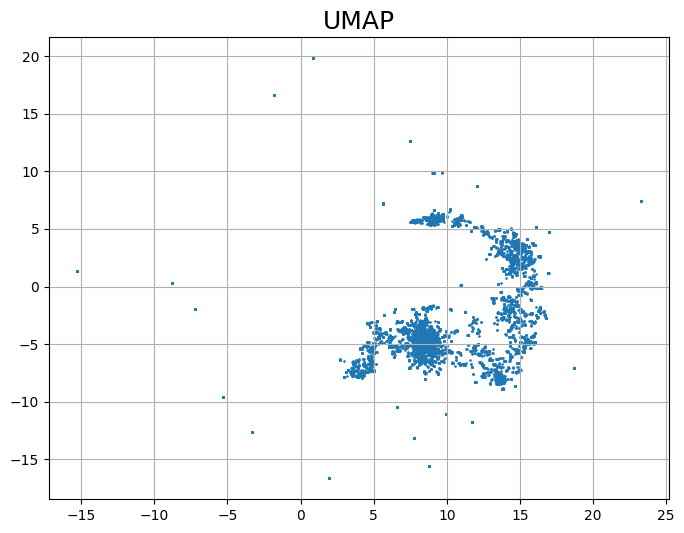

In [24]:
#Plotting the projection of data:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=0.8)
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

#### Clustering Algorithm results:

##### KMeans

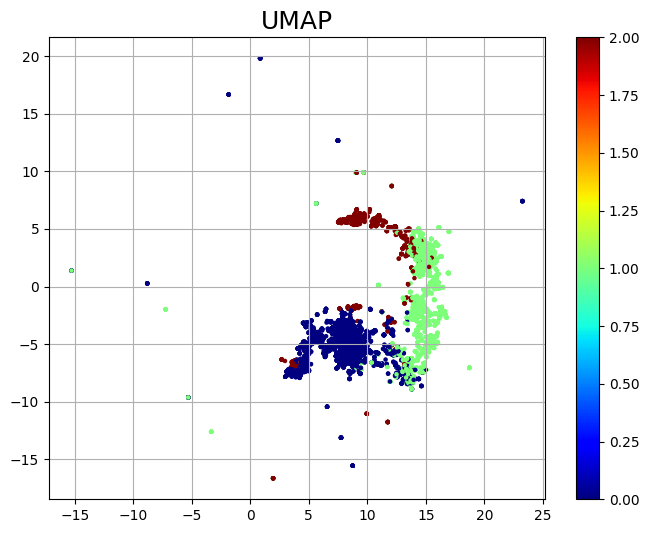

In [25]:
#KMeans as a simple version first:
kmeans = cluster.KMeans(n_clusters=3, n_init="auto").fit(image_pixel_dataframe_norm)
colours = kmeans.labels_
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=5, c = colours, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

(10.0, 70.0)

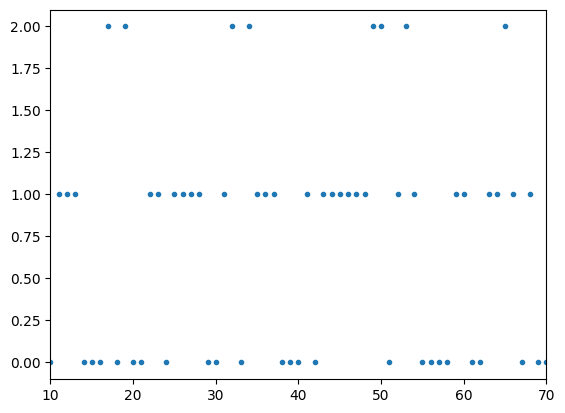

In [26]:
#Plotting the labels to check for patterns:
plt.plot(kmeans.labels_, ".")
plt.xlim(10, 70)

##### DBSCAM

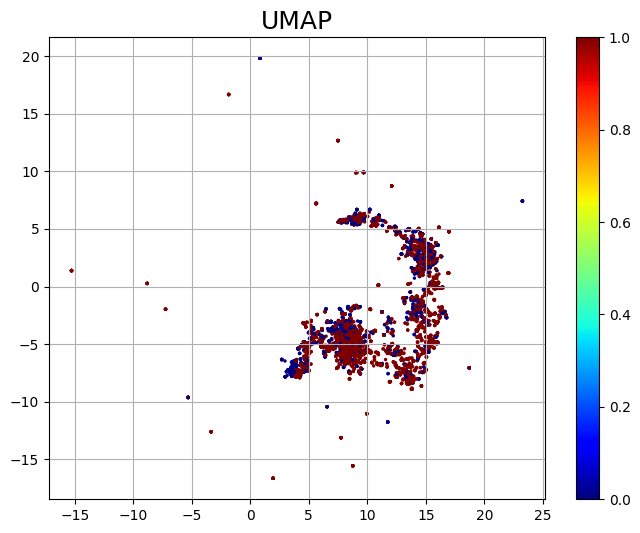

In [27]:
dbscan = cluster.DBSCAN(eps=0.5, min_samples=15).fit(image_pixel_dataframe_norm)
colours_db = dbscan.labels_+1
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=2.2, c = colours_db, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

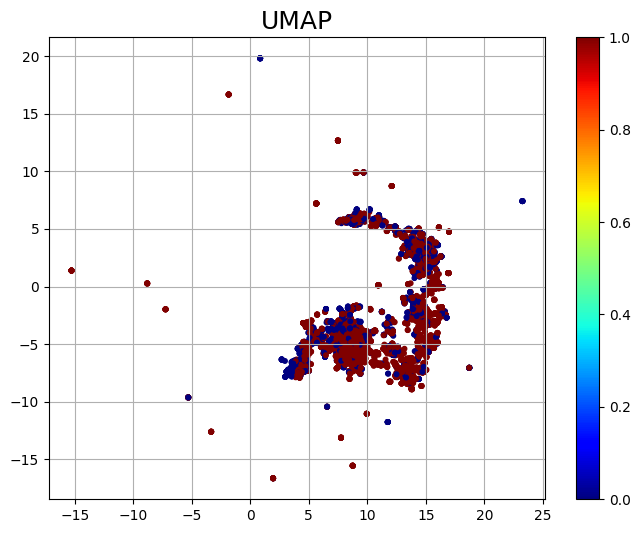

In [28]:
colours_db = dbscan.labels_+1
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=10.8, c = colours_db, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

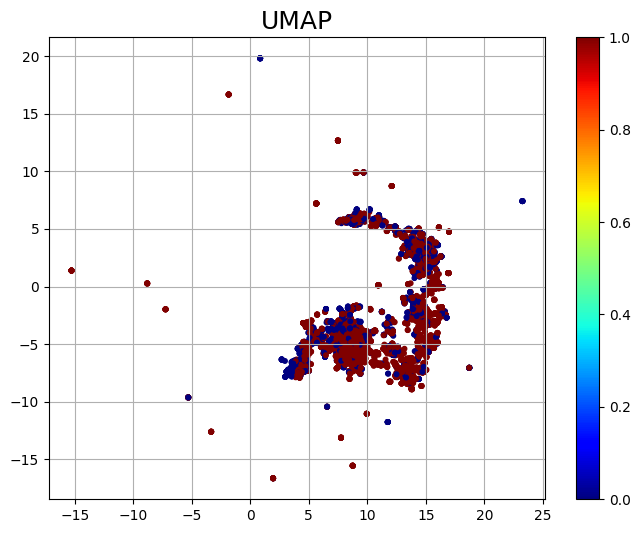

In [29]:
colours_db = dbscan.labels_+1
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=10.8, c = colours_db, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

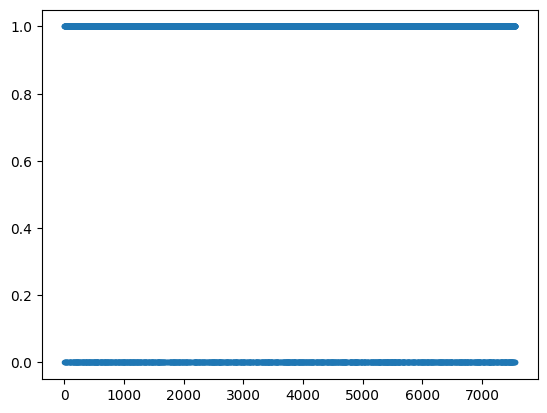

In [30]:
plt.plot(dbscan.labels_+1, ".")

#### Spectral clustering

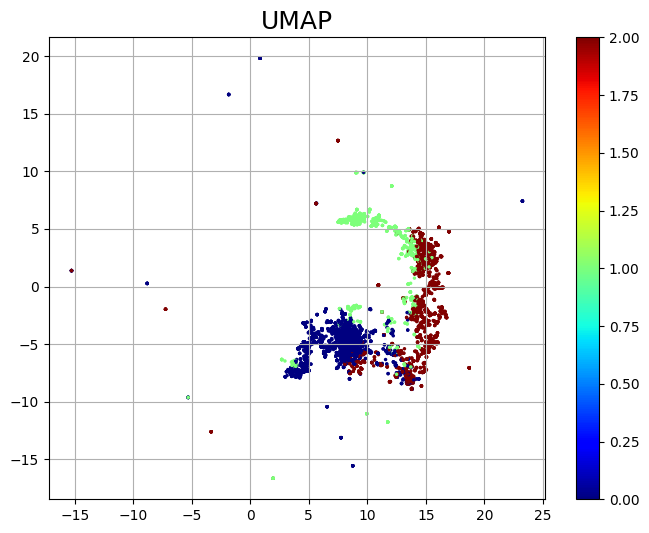

In [31]:
spectral = cluster.SpectralClustering(assign_labels="discretize", n_clusters=3, random_state=42).fit(image_pixel_dataframe_norm)
colours_spec = spectral.labels_
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=2.2, c = colours_spec, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

#### Optics

C:\Users\ludvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\cluster\_optics.py:1084: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


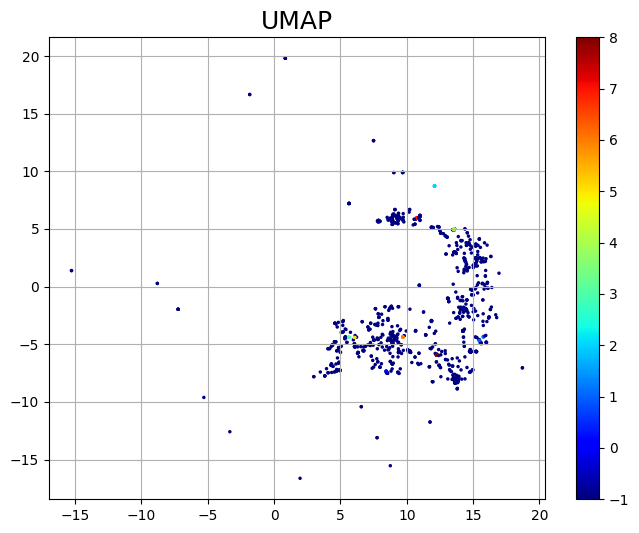

In [32]:
optics = cluster.OPTICS(min_samples=5).fit(image_pixel_dataframe_norm[:1000])
colours_opt = optics.labels_
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0][:1000], umap_2D_projection[:, 1][:1000], s=2.2, c = colours_opt, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

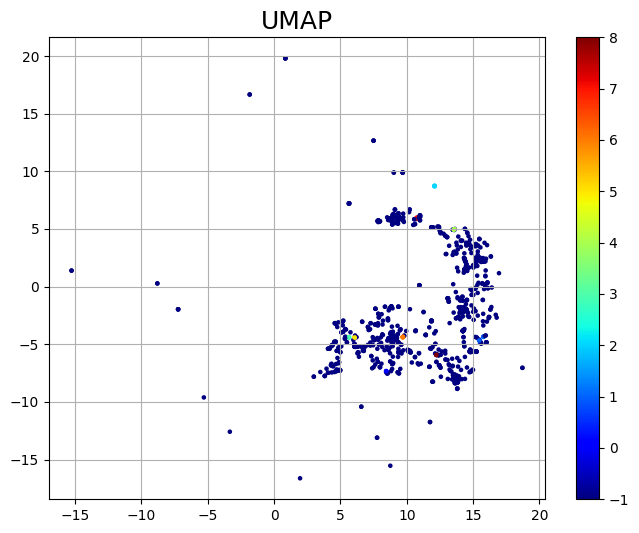

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0][:1000], umap_2D_projection[:, 1][:1000], s=5.2, c = colours_opt, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

ANYTHING THAT RELATES TO DBSCAN IS TERRIBLE(Note: This comment may not be deleted under any circumstances)

### Trying sklearns dedicated outlier detection tools:

#### IsolationForest

In [34]:
iso_forest = IsolationForest(max_samples=250, n_estimators=500, max_features=3, random_state=42)
iso_forest.fit(image_pixel_dataframe_norm)
isolated_forest = iso_forest.predict(image_pixel_dataframe_norm)

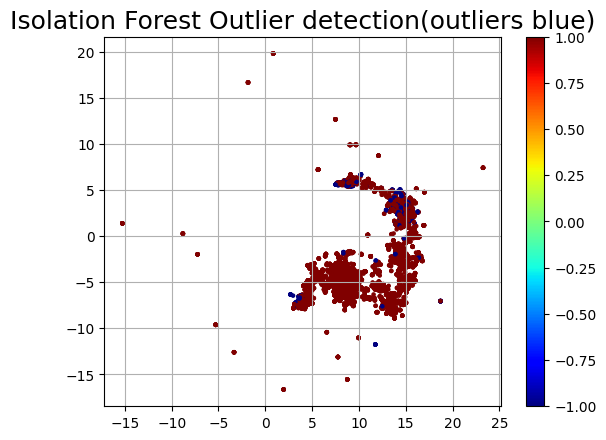

In [35]:
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=5.2, c = isolated_forest, cmap="jet")
plt.colorbar()
plt.title("Isolation Forest Outlier detection(outliers blue)", fontsize=18)
plt.grid()
plt.show()

In [36]:
numpy_image_pixel_comp[colours_db == 1].T[-1]

array(['2025-04-20___0_right.webp', '2025-04-20___1_left.webp',
       '2025-04-20___1_right.webp', ..., '2026-05-19___7_right.webp',
       '2026-05-19___8_left.webp', '2026-05-19___8_right.webp'],
      shape=(5673,), dtype=object)

#### Local Outlier Factor

In [37]:
factor_algo = LocalOutlierFactor(n_neighbors=10)
factor_algo_results = factor_algo.fit_predict(image_pixel_dataframe_norm)

C:\Users\ludvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


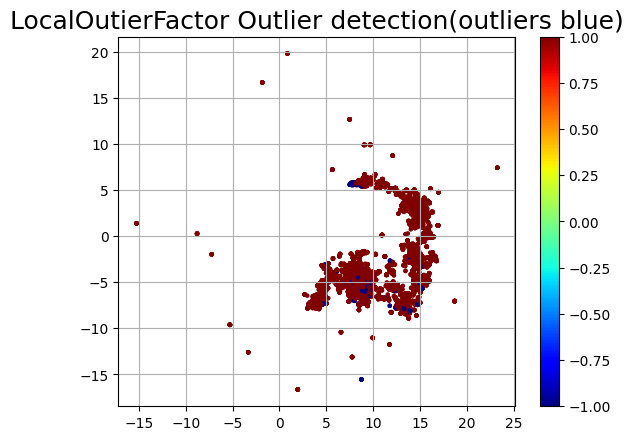

In [38]:
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=5.2, c = factor_algo_results, cmap="jet")
plt.colorbar()
plt.title("LocalOutierFactor Outlier detection(outliers blue)", fontsize=18)
plt.grid()
plt.show()

In [39]:
numpy_image_pixel_comp[factor_algo_results == -1].T[-1][210]

'2026-01-19___1_right.webp'

In [40]:
np.argmax(umap_2D_projection[:, 0][factor_algo_results == -1])

np.int64(48)

In [41]:
umap_2D_projection[:, 0][factor_algo_results == -1][210]

np.float32(8.757508)

### Doing stuff with the limited non-image data:


In [42]:
non_image_vars = ["year", "rating", "price"]
low_var_image_pixel = image_pixel_dataframe_no_NaN[non_image_vars]


In [43]:
#Normalizing the data:
image_pixel_low_var_dataframe_norm = pd.DataFrame(preprocessing.normalize(low_var_image_pixel))

In [44]:
image_pixel_low_var_dataframe_norm

,0,1,2
0,0.999918,0.012759,0.001286
1,0.998988,0.044740,0.004691
2,0.999870,0.016071,0.001385
3,0.999197,0.040027,0.001680
4,0.998982,0.045036,0.002716
...,...,...,...
7549,0.999969,0.007385,0.002570
7550,0.999898,0.014169,0.001678
7551,0.999615,0.027605,0.002714
7552,0.999631,0.025910,0.008133


In [45]:
umap_projector_low_var = umap.UMAP(n_components=2, n_neighbors=50, random_state=42).fit(image_pixel_low_var_dataframe_norm)
umap_2D_projection_low_var = umap_projector_low_var.fit_transform(image_pixel_low_var_dataframe_norm)

C:\Users\ludvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


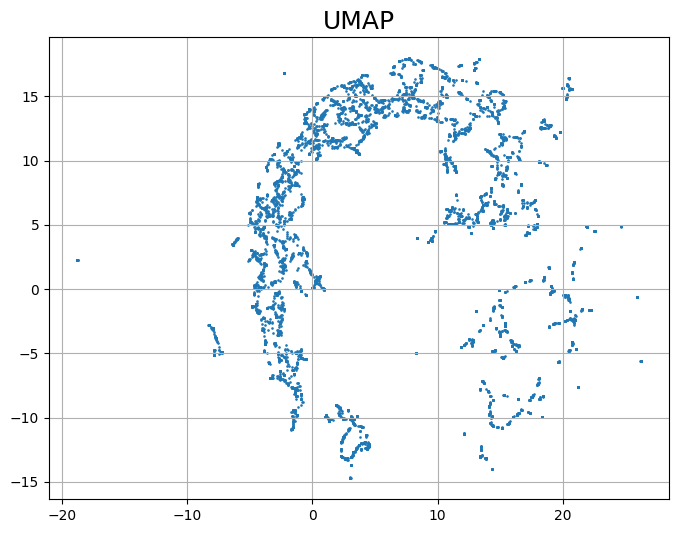

In [46]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection_low_var[:, 0], umap_2D_projection_low_var[:, 1], s=0.8)
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

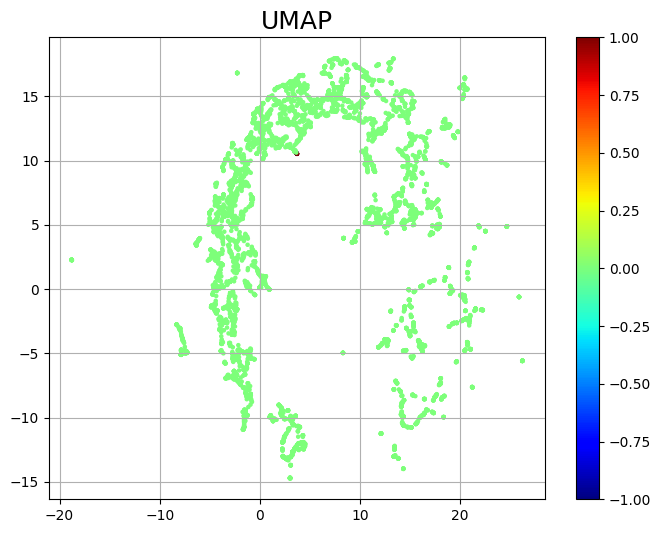

In [47]:
kmeans = cluster.DBSCAN(eps=0.03).fit(image_pixel_low_var_dataframe_norm)
colours = kmeans.labels_
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection_low_var[:, 0], umap_2D_projection_low_var[:, 1], s=5, c = colours, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

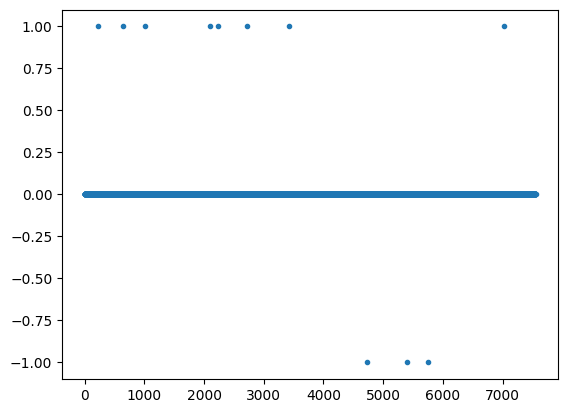

In [48]:
plt.plot(kmeans.labels_, ".")

In [2]:
from sklearn.feature_extraction.text import CountVectorizer


In [ ]:
def data_processor(path):
    data = {}
    date_list = sorted(os.listdir(path))
    text_list = []
    for date in date_list:
        meta_path = os.path.join(path, date, "meta.csv")
        data[date] = {}
        data[date] = pd.read_csv(meta_path,sep=",").fillna("")
        for index, row in data[date].iterrows():
            text_list.append(f"{row["title"]} {row["subtitle"]} {row["country"]} {row["club"]}")
    return data, text_list


In [51]:
path = r"..\data\grand_scraper_folder\scrandle_data"

In [52]:
data, text_list = data_processor(path)

In [53]:
text_list

['Hot dog in a waffle  NOR Fredrikstad FK',
 'Chicharrones Fried pork belly with guac and chimichurri NZL Eden Park',
 'Sánguche de potito Cows rectum sandwich CHI Universidad de Chile',
 'Turkey schnitzel  GER Borussia Monchengladbach',
 'Katsu chicken curry  JPN Super Cup Final',
 'Samosas  IND Bengaluru FC',
 'Cheeseburger  ENG Crewe Alexandra',
 'BBQ pulled beef and pork grilled cheese  ENG Man City',
 'Sanduíche de Costela (Rib meat) BRA Clube Atletico Paranaense',
 'Steak and peppercorn sauce With chips ENG Man City',
 'Jerk chicken and cornbread fritters  ENG Hanwell Town',
 'Nackensteak im brötchen Steak in a bun GER Meiendorfer SV',
 'Thai noodles With crispy chicken balls ENG Bolton Wanderers',
 'Steak and black pudding pie  SCO Arbroath FC',
 'Crispy pork belly  THA Police Tero FC',
 'Poutine  ENG Aston Villa',
 'Chicken tikka, naan and masala fries  ENG Wolves FC',
 'Balti pie With a cuppa ENG Walsall FC',
 "Unidentified food We're at the cricket today ENG Edgbaston",
 'Can

In [54]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(text_list)

In [55]:
for i in range(len(vectorizer.get_feature_names_out())):
    print(vectorizer.get_feature_names_out()[i])

03
04
08
10
100
11
16
18
1905
1991
1995
1lb
200
2008
2015
2022
2023
2024
2025
22oz
23
24oz
2ft
2lb
2x
38
3lbs
47
49ers
4lb
4pc
4x
5l
5lb
60
64
67
67oz
6oz
75
78f00
7v7
93
aarau
abbey
aberdeen
aberdeid
abura
ac
academy
acaraje
acarajé
accommodation
accor
accrington
achari
achna
actaea
aculeatus
ad
add
added
adelaide
admission
aek
aeros
afc
after
agaric
agaricus
age
ahead
ahmad
ahogada
aioli
air
airbus
airdrieonians
ajax
ajvar
akadémia
akh
al
albans
albion
albirex
alcoholic
alcorcon
ale
alebrijes
alejandro
aleuria
alex
alexandra
algeria
ali
alianza
alkmaar
all
allegiant
alloa
almeria
almond
aloo
also
altona
altrincham
am
amanita
amazin
amazing
amber
american
amex
amstel
amsterdam
amtrak
an
anaheim
anchovies
and
andalouse
anderlecht
anfield
angel
angeles
angels
angus
animal
annan
anti
antichucho
antigua
antlers
antonio
antwerp
any
apple
aquifolium
arab
arbroath
ardija
are
arena
arg
argentine
argentinian
argentino
argyle
arizona
arka
armadale
arminia
arndale
aronia
arrachera
arsenal
artois

In [56]:
X.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(7900, 3554))

In [59]:
np.shape(X)

(7900, 3554)

In [60]:
umap_projector = umap.UMAP(n_components=2, n_neighbors=50, random_state=42).fit(X)
umap_2D_projection = umap_projector.fit_transform(X)

C:\Users\ludvi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


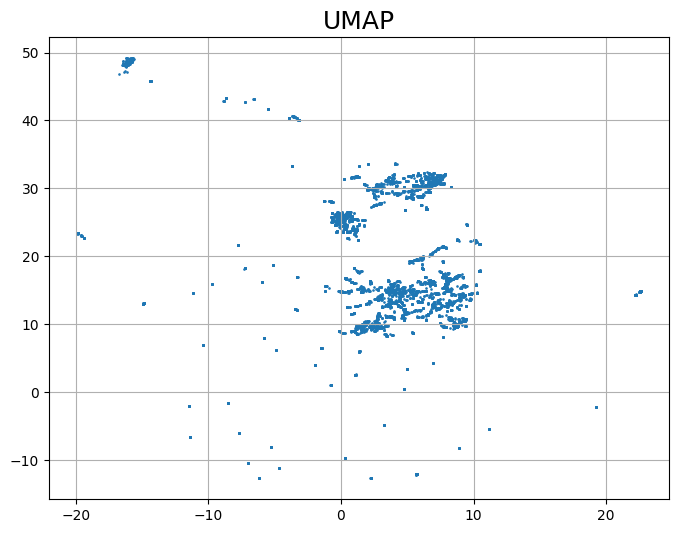

In [61]:
#Plotting the projection of data:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=0.8)
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

In [69]:
dbscan = cluster.KMeans(n_clusters=2).fit(X)
colours_db = dbscan.labels_+1

(-12.0, -2.0)

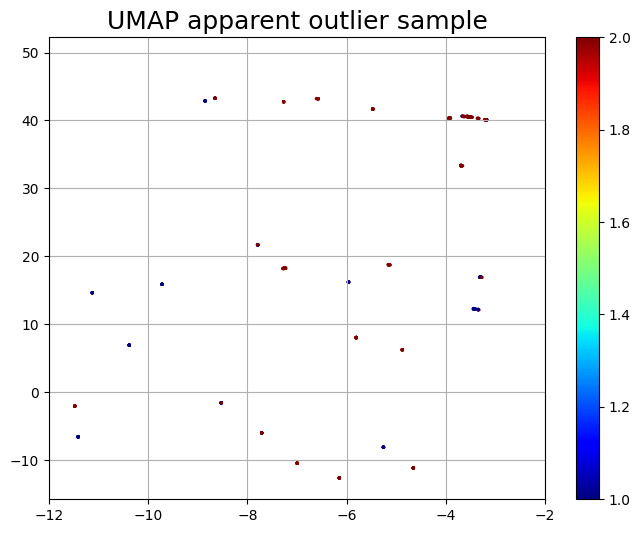

In [101]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=2.2, c = colours_db, cmap="jet")
plt.colorbar()
plt.title("UMAP apparent outlier sample", fontsize=18)
plt.grid()
#plt.show()
plt.xlim(-12,-2)

In [102]:
print("apparent outlier texts")
for i in range(len(umap_2D_projection)):
    if -12 < umap_2D_projection[:, 0][i] < -8 and -10 < umap_2D_projection[:,1][i] < 20:
        print(text_list[i])
        print(i)

apparent outlier texts
Yorkshire pudding wrap Filled with sausages and stuffing, with a pot of gravy ENG Derby County
234
Pork and stuffing roll With crackling ENG Reading FC
266
The gaffer burger 6oz beef patty with lettuce, cheese, crispy chicken strips, bacon and crispy onions ENG Tilbury FC
273
Sziros Kenyer Bread, lard, paprika and raw onion HUN MTK Budapest
287
Sziros Kenyer Bread, lard, paprika and raw onion HUN MTK Budapest
332
Yorkshire pudding wrap Filled with sausage and stuffing, with a gravy dip ENG Derby County
563
Yorkshire pudding wrap Filled with sausage and stuffing, with a gravy dip ENG Derby County
699
Pork and stuffing roll With crackling ENG Reading FC
710
Soy & Honey Beef Brisket Size 7 sandwich With waffle fries and a scotch egg ENG Grimsby Town
715
Fish finger sandwich  ENG York City
717
The gaffer burger 6oz beef patty with lettuce, cheese, crispy chicken strips, bacon and crispy onions ENG Tilbury FC
835
Yorkshire pudding wrap Filled with sausage and stuffing

In [104]:
index_list = []
string = "Woods"
print("mushroom texts and indices")
for i in range(len(text_list)):
    if string in text_list[i]:
        print(text_list[i])
        print(i)
        index_list.append(i)

mushroom texts and indices
Chicken Of The Woods Laetiporus sulphureus ENG The Woods
4580
Devil's Bolete Rubroboletus satanas ENG The Woods
4581
Destroying Angel Amanita virosa ENG The Woods
4582
Deer Shield Pluteus cervinus ENG The Woods
4583
Fool's Funnel Clitocybe rivulosa ENG The Woods
4584
Splendid Waxcap Hygrocybe splendidissima ENG The Woods
4585
Fly Agaric Amanita muscaria ENG The Woods
4586
Orange Peel Fungus Aleuria aurantia ENG The Woods
4587
The Blusher Amanita rubescens ENG The Woods
4588
Poison Pie Heboloma crustuliniforme ENG The Woods
4589
Coral Tooth Hericium coralloides ENG The Woods
4590
Deathcap Amanita phalloides ENG The Woods
4591
Chanterelle Cantharellus cibarius ENG The Woods
4592
False Morel Gyromitra esculenta ENG The Woods
4593
The Sickener Russula emetica ENG The Woods
4594
Almond Mushroom Agaricus subrufescens ENG The Woods
4595
Bearded Milkcap Lactarius pubescens ENG The Woods
4596
Scarlet Elfcup Sarcoscypha austriaca ENG The Woods
4597
Funeral Bell Galerin

In [100]:
print("mushroom positions")
for i in index_list:
    print(umap_2D_projection[:, 0][i], umap_2D_projection[:, 1][i])

mushroom positions
8.36867 14.416393
8.42291 14.42445
8.402046 14.44175
8.408185 14.442505
8.398524 14.449035
8.403837 14.437811
8.381633 14.459195
8.398852 14.45359
8.398538 14.423338
8.532705 14.445996
8.390166 14.460497
8.392903 14.433392
8.43383 14.409644
8.361078 14.447479
8.385037 14.441921
8.412119 14.440158
8.408792 14.436779
8.434957 14.414322
8.37643 14.43633
8.394077 14.443666


(14.4, 14.5)

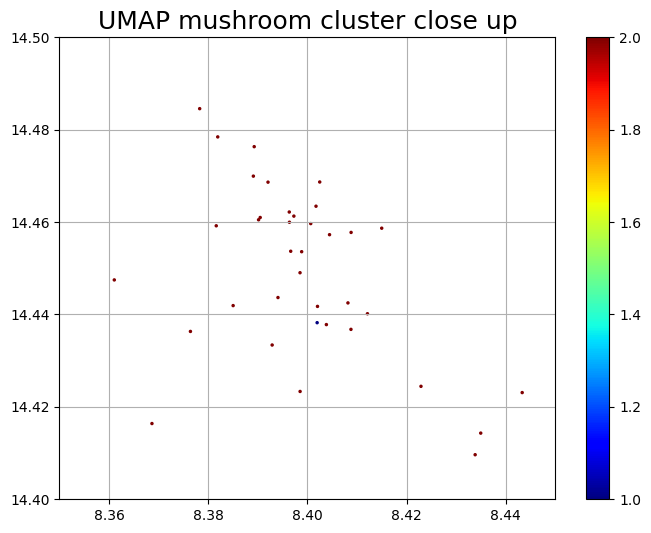

In [99]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=2.2, c = colours_db, cmap="jet")
plt.colorbar()
plt.title("UMAP mushroom cluster close up", fontsize=18)
plt.grid()
#plt.show()
plt.xlim(8.35,8.45)
plt.ylim(14.4,14.5)

In [90]:
for i in range(len(umap_2D_projection)):
    if 8.35 < umap_2D_projection[:, 0][i] < 8.45 and 14.4 < umap_2D_projection[:,1][i] < 14.5:
        print(text_list[i])
        print(i)

Nachos  ENG The Etihad
3455
Bovril "strong enough to melt the cutlery" ENG Dagenham & Redbridge
3470
Nachos  ENG The Etihad
3486
Fish free for Martin Odegaard, the man of the match ESP Real Sociedad
4084
Bovril "strong enough to melt the cutlery" ENG Dagenham & Redbridge
4164
Fish free for Martin Odegaard, the man of the match ESP Real Sociedad
4231
Chicken Of The Woods Laetiporus sulphureus ENG The Woods
4580
Devil's Bolete Rubroboletus satanas ENG The Woods
4581
Destroying Angel Amanita virosa ENG The Woods
4582
Deer Shield Pluteus cervinus ENG The Woods
4583
Fool's Funnel Clitocybe rivulosa ENG The Woods
4584
Splendid Waxcap Hygrocybe splendidissima ENG The Woods
4585
Fly Agaric Amanita muscaria ENG The Woods
4586
Orange Peel Fungus Aleuria aurantia ENG The Woods
4587
The Blusher Amanita rubescens ENG The Woods
4588
Coral Tooth Hericium coralloides ENG The Woods
4590
Deathcap Amanita phalloides ENG The Woods
4591
Chanterelle Cantharellus cibarius ENG The Woods
4592
False Morel Gyrom

(14.1, 14.8)

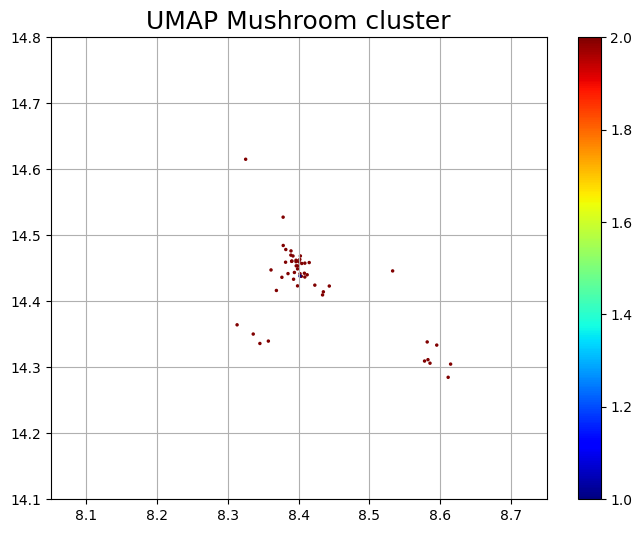

In [96]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=2.2, c = colours_db, cmap="jet")
plt.colorbar()
plt.title("UMAP Mushroom cluster", fontsize=18)
plt.grid()
#plt.show()
plt.xlim(8.05,8.75)
plt.ylim(14.1,14.8)

(13.1, 15.8)

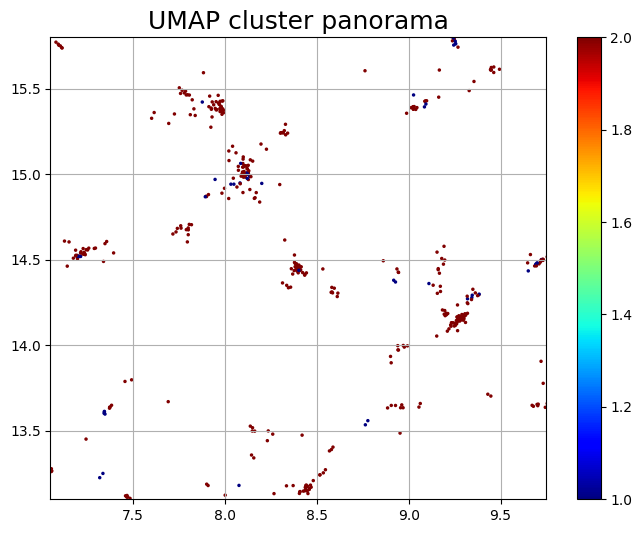

In [97]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=2.2, c = colours_db, cmap="jet")
plt.colorbar()
plt.title("UMAP cluster panorama", fontsize=18)
plt.grid()
#plt.show()
plt.xlim(7.05,9.75)
plt.ylim(13.1,15.8)

(14.7, 15.4)

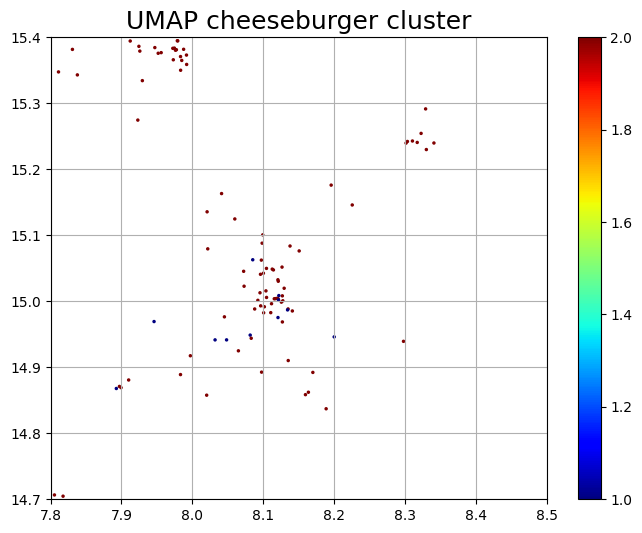

In [98]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=2.2, c = colours_db, cmap="jet")
plt.colorbar()
plt.title("UMAP cheeseburger cluster", fontsize=18)
plt.grid()
#plt.show()
plt.xlim(7.8,8.5)
plt.ylim(14.7,15.4)

In [105]:
print("cheeseburger cluster texts")
for i in range(len(umap_2D_projection)):
    if 8 < umap_2D_projection[:, 0][i] < 8.3 and 14.8 < umap_2D_projection[:,1][i] < 15.2:
        print(text_list[i])
        print(i)

cheeseburger cluster texts
Kebab  ENG Fulham FC
48
Cheeseburger  ENG Chesterfield FC
239
Cheeseburger  ENG Walsall FC
378
Cheeseburger  ENG Portsmouth FC
528
Cheeseburger  ENG Portsmouth FC
602
Kebab  ENG Fulham FC
751
Cheeseburger  ENG Chesterfield FC
887
Onion bhajis  ENG Slough Town FC
1077
Nachos  ENG Barnsley FC
1139
Lasagne  ENG Hendon FC
1566
Cheeseburger  ENG Chesterfield FC
1802
Yorkshire pudding wrap  ENG Portsmouth FC
1882
Cheeseburger  ENG Portsmouth FC
2006
Berries Free from a bush ENG Basildon United FC
2093
Yorkshire pudding wrap  ENG Portsmouth FC
2158
Cheeseburger  ENG Walsall FC
2193
Nachos  ENG Barnsley FC
2271
Yorkshire pudding wrap  ENG Portsmouth FC
2328
Kebab  ENG Fulham FC
2522
Cheeseburger  ENG Walsall FC
2574
Cheeseburger  ENG Chesterfield FC
2718
Cheeseburger  ENG Walsall FC
2796
Nachos  ENG Barnsley FC
2975
Lasagne  ENG Hendon FC
3164
Donuts and crepes  ENG Farnborough FC
3172
Cheeseburger  ENG Portsmouth FC
3240
Cheeseburger  ENG Chesterfield FC
3384
Cheese

In [111]:
print("burger cluster texts")
for i in range(len(umap_2D_projection)):
    if 7.7 < umap_2D_projection[:, 0][i] < 8 and 15.2 < umap_2D_projection[:,1][i] < 15.5:
        print(text_list[i])
        print(i)

burger cluster texts
Hot dog  ENG Towlaw Town FC
99
The burger dog  ENG Warrington Town FC
156
Macies ultimate burger  ENG Avro FC
250
The burger dog  ENG Warrington Town FC
573
Borough burger Two beef patties with cheese ENG Eastbourne Borough FC
700
Burger  ENG Chesterfield FC
770
Streetwise burger Beef patty, cheese, pulled pork, onion rings ENG Tilbury FC
898
Burger  ENG Chesterfield FC
1093
Double mega burger  ENG Winstanley Warriors FC
2125
Hot dog  ENG Towlaw Town FC
2763
Burger  ENG Chesterfield FC
2951
Burger  ENG Chesterfield FC
3106
Burger  ENG Chesterfield FC
3293
Hot dog  ENG Towlaw Town FC
3308
Hawk Burger  ENG Whitehawk FC
3502
Burger  ENG Bromley FC
3775
Streetwise Burger  ENG Tilbury FC
4069
Streetwise Burger  ENG Tilbury FC
4242
Hot Dog  ENG Hertford Town FC
4280
The Boro burger  ENG Stevenage FC
4389
Hot dog  ENG Kings Lynn Town FC
4486
Macies ultimate burger  ENG Avro FC
4571
Hawk Burger  ENG Whitehawk FC
4741
Street chick burger  ENG Tilbury FC
4811
The Legend Burg

(15.2, 15.5)

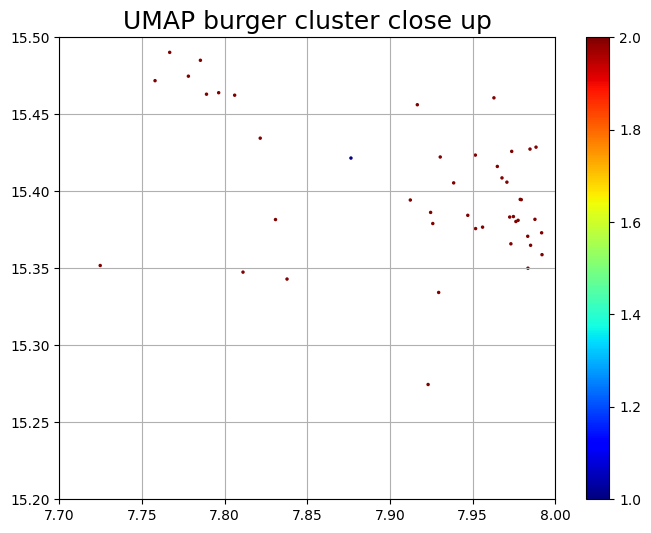

In [110]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=2.2, c = colours_db, cmap="jet")
plt.colorbar()
plt.title("UMAP burger cluster close up", fontsize=18)
plt.grid()
plt.xlim(7.7,8)
plt.ylim(15.2,15.5)

In [9]:
import pandas as pd
import os
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer


In [10]:
def data_processor(path):
    text_list = []
    data =pd.read_csv(path,sep=",").fillna("")
    for index, row in data.iterrows():
        text_list.append(f"{row["title"]} {row["subtitle"]} {row["country"]} {row["club"]}")
    return data, text_list

In [11]:
path = r"..\data\grand_scraper_folder\unique_scrandle_pictures_FULL.csv" 
data, text_list = data_processor(path)

In [12]:
print(len(text_list))
print(text_list)

3193
['Double cheeseburger With sausage and bacon ENG Torquay United F.C.', 'Poutine Chips, cheese and gravy CAN CF Montréal', 'Chicken bucket  USA New York City FC', 'Meat and potato pie With chips, peas and gravy ENG Atherton Collieries', 'German doner kebab  ENG Ebbsfleet United F.C.', 'Nachos With beef chili and cheese sauce ENG Arsenal F.C.', 'Wild sausages  DEN F.C. Copenhagen', 'Dairy milk doughnut  ENG Tottenham Hotspur F.C.', 'Chicken biryani  ENG Leicester Nirvana', 'Double cheeseburger  ENG Yeovil Town F.C.', 'Two battered sausages With chips and curry sauce IRL Shamrock Rovers F.C.', '4 chicken tenders With chips ENG Everton F.C.', 'Popcorn chicken and chips  ENG Wakefield AFC', 'Cheese quesadilla With a pint USA LA Rams', 'Smash burger  ENG Hartley Wintney F.C.', 'Pie and chips With mushy peas and curry sauce ENG Altrincham F.C.', 'The Skyrosa Cheese coney on top of a pizza slice USA FC Cincinnati', 'Stadionwurst In a bun with mustard GER Rheinergie Stadion, Köln', 'Burger

In [13]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(text_list)

In [23]:
print(X[0])
print(text_list[0])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 9 stored elements and shape (1, 3648)>
  Coords	Values
  (0, 1028)	1
  (0, 652)	1
  (0, 3552)	1
  (0, 2816)	1
  (0, 125)	1
  (0, 226)	1
  (0, 1113)	1
  (0, 3289)	1
  (0, 3378)	1
Double cheeseburger With sausage and bacon ENG Torquay United F.C.


In [24]:
print(vectorizer.get_feature_names_out()[1028])
print(vectorizer.get_feature_names_out()[652])
print(vectorizer.get_feature_names_out()[3552])
print(vectorizer.get_feature_names_out()[2816])
print(vectorizer.get_feature_names_out()[125])
print(vectorizer.get_feature_names_out()[226])
print(vectorizer.get_feature_names_out()[1113])
print(vectorizer.get_feature_names_out()[3289])
print(vectorizer.get_feature_names_out()[3378])


double
cheeseburger
with
sausage
and
bacon
eng
torquay
united


In [15]:
for i in range(len(vectorizer.get_feature_names_out())):
    print(vectorizer.get_feature_names_out()[i])

03
04
08
10
100
11
16
18
1889
1905
1965
1991
1995
1lb
200
2008
2015
2022
2023
2024
2025
22oz
23
24oz
2ft
2lb
2x
38
3lbs
47
49ers
4lb
4pc
4x
5l
5lb
60
64
67
67oz
6oz
75
78f00
7v7
93
aarau
abbey
aberdeen
aberdeid
abura
ac
academy
acaraje
acarajé
accommodation
accor
accrington
achari
achna
actaea
aculeatus
ad
add
added
adelaide
admission
aek
aeros
afc
after
agaric
agaricus
age
ahead
ahmad
ahogada
aioli
air
airbus
airdrieonians
ajax
ajvar
akadémia
akh
al
albans
albion
albirex
albuquerque
alcoholic
alcorcon
ale
alebrijes
alejandro
aleuria
alex
alexandra
algeria
ali
alianza
alkmaar
all
allegiant
allianz
alloa
almeria
almond
almonds
aloo
also
altona
altrincham
am
amanita
amazin
amazing
amber
american
amphitheater
amstel
amsterdam
amtrak
an
anaheim
anchovies
and
andalouse
anderlecht
anfield
angel
angeles
angels
anger
angus
animal
annan
anti
antichucho
antigua
antlers
antonio
antwerp
any
apple
aquifolium
arab
arbroath
ardija
are
arena
arg
argentine
argentinian
argentino
argyle
arizona
arka
arma